<img src="../img/Logo.png" width="100"/>

![logo](../img/Recurso-6.png)

### ***Cargo:*** Docente Especialista
### ***Nombre:*** Ing. Elvis Pachacama
### ***Asignatura:*** Machine E-Learning
### ***Carrera:*** Desarrollo de Software &nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp; ***Nivel:*** Cuarto Nivel
### ***Estudiante:*** Rueda Gaona Félix <br>

## Repositorio: 
https://github.com/FelixR93/Maquine-E-Learning/blob/main/examen/Examen_Tercer_parcial.ipynb


# Examen del Tercer Parcial 
## Regresión lineal
Dado el archivo **movie_genre_classification_final.csv** se encuentra un base de datos con información de **50000 películas** que incluyen variables como: <br>
 * Título,
 * Año de estreno,
 * Duración,
 * Puntuación promedio,
 * Número de votos,
 * Presupuesto,
 * Ingresos en taquilla,
 * Número de premios obtenidos,
 * Entre otras caracterisiticas.
Como parate del análisis de predicción, se desea estudiar la relación entre el:<br>
* Presupuesto de una película
y sus caracteristicas cuantitativas, para estimar la **recaudación en taquilla (BoxOffice_USD)**. Para ello, se plantea entrenar un modelo de regresión lineal.<br>

# Objetivo 
Predecir el valor de la variable **BoxOffice_USD** a partir de variables numéricas independientes disponibles en el dataset, tales como:<br>
* Budget_USD (Presupuesto en dólares)
* Duration (Duración en minutos)
* Ratting (Calificiación Promedio"
* Votes (Número de votos)
* Num_Awards (Número de premios obtenidos)
* Critic_reviews (Números de reseñas de criticos)

El dataset fue extraido desder <a href="https://www.kaggle.com/datasets/therohithanand/movie-genre-classification">DataSet<a> <br>

## Entrega esperada
* Código bien estructurado y comentado
* Gráficos claros en los pasos 2, 4 y 5.
* Breve análisis escrito de lso los resultados obtenidos.



In [33]:
# Importamos las librerias necesarias
import pandas as pd                  # Los utilizamos para majerar los datos en las tablas
import matplotlib.pyplot as plt      # Nos sive para los graficos
import seaborn as sns                # Graficos esteticos
from sklearn.linear_model import LinearRegression    # Se lo utiliza para el Modelo de regresión Lineal
from sklearn.model_selection import train_test_split  # Lo utilizamos para separa los datos en entrenamiento y pruebas
from sklearn.metrics import mean_squared_error, r2_score  #Nos sirve para evaluar el modelo

In [34]:
# 1. Lectura de datos
# comando para leer nuestro archivo CSV
df = pd.read_csv('movie_genre_classification_final.csv')

# Mostramos las primeras filas para verificar como esta los datos
print(df.head())

             Title  Year  Director  Duration  Rating   Votes  \
0  Winds of Fate 4  1980    R. Lee       167     4.1  182425   
1     Firestorm 11  2014   S. Chen       166     4.1  449351   
2    Silent Echo 2  2016   A. Khan       170     4.1  363328   
3    City Lights 4  1982  L. Zhang       170     9.9   62371   
4   Broken Truth 1  1990  L. Zhang        91     5.3    4600   

                                         Description  Language Country  \
0   A touching love story with heartwarming moments.   Spanish   China   
1  A fast-paced thriller with intense action scenes.    Korean   China   
2  A fast-paced thriller with intense action scenes.    Korean   Japan   
3  An emotional journey exploring complex charact...  Japanese   Japan   
4  An imaginative world filled with magic and won...    Korean     USA   

   Budget_USD  BoxOffice_USD    Genre Production_Company Content_Rating  \
0    39979615      179936008  Romance         DreamWorks              R   
1   116404774      8

In [52]:
# 2. Visualización del conjunto de datos
# Mostramos las estadisticas para conocer las variables numéricas
df.describe()

,Year,Duration,Rating,Votes,Budget_USD,BoxOffice_USD,Num_Awards,Critic_Reviews
count,50000.000000,50000.00000,50000.000000,50000.000000,5.000000e+04,5.000000e+04,50000.000000,50000.000000
mean,2001.562620,130.07312,6.926472,249699.050540,9.179143e+07,5.176063e+08,9.964440,500.176380
std,12.722539,29.11097,1.698758,144314.043032,5.823888e+07,2.880283e+08,6.066303,289.971792
min,1980.000000,80.00000,4.000000,516.000000,1.135566e+06,3.291117e+06,0.000000,0.000000
25%,1991.000000,105.00000,5.500000,124531.500000,4.389040e+07,2.590329e+08,5.000000,248.000000
50%,2002.000000,130.00000,6.900000,248582.000000,8.062480e+07,5.109973e+08,10.000000,500.000000
75%,2013.000000,155.00000,8.400000,374833.500000,1.475557e+08,7.704129e+08,15.000000,751.000000
max,2023.000000,180.00000,9.900000,499984.000000,1.984445e+08,9.925159e+08,20.000000,1000.000000


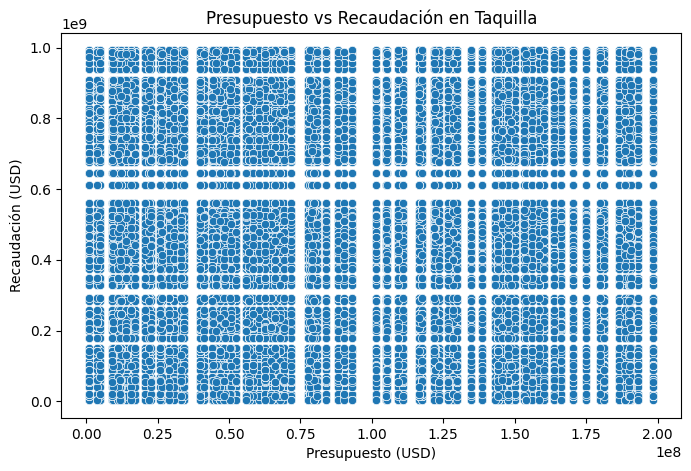

In [53]:
# 2. Visualización del conjunto de datos
# Creamos nuestro Gráfico para ver cómo se relacionan entre Presupuesto y Recaudación
plt.figure(figsize=(8,5))
sns.scatterplot(x='Budget_USD', y='BoxOffice_USD', data=df)
plt.title('Presupuesto vs Recaudación en Taquilla')
plt.xlabel('Presupuesto (USD)')
plt.ylabel('Recaudación (USD)')
plt.show()

In [36]:
# 3. Modificación del conjutno de datos
# Seleccionamos solo las columnas que vamos a usar
variables = ['Budget_USD', 'Duration', 'Rating', 'Votes', 'Num_Awards', 'Critic_Reviews', 'BoxOffice_USD']

# Filtramos el DataFrame con solo esas columnas y eliminar filas con datos faltantes
df_model = df[variables].dropna()

# Verificamos la estructura limpia
print(df_model.head())

   Budget_USD  Duration  Rating   Votes  Num_Awards  Critic_Reviews  \
0    39979615       167     4.1  182425           8             229   
1   116404774       166     4.1  449351          20             466   
2   166261330       170     4.1  363328          16             539   
3    28861315       170     9.9   62371          15             606   
4    43890403        91     5.3    4600           6             330   

   BoxOffice_USD  
0      179936008  
1      802121619  
2      225526871  
3       69813738  
4      375136716  


Error cuadrático medio (MSE): 83696224592480544.00
Coeficiente de determinación (R²): -0.0005


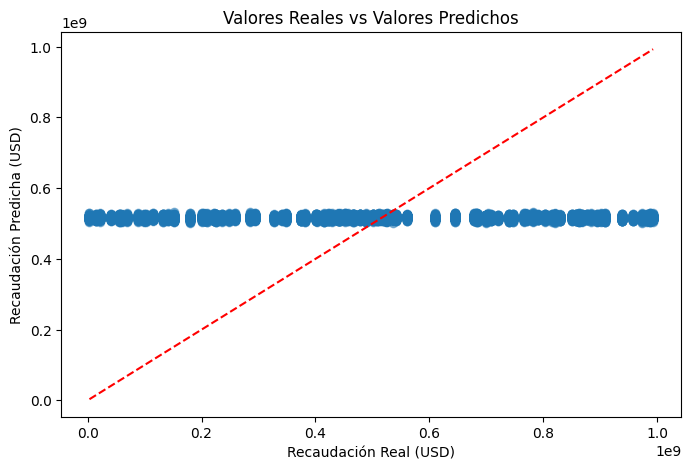

In [54]:
# 4. Construcción del modelo de regresión lineal
# Separamos las variables independientes (X) y la variable dependiente (y)
X = df_model.drop('BoxOffice_USD', axis=1) # Todas menos la recaudación
y = df_model['BoxOffice_USD'] # La recaudación, que queremos predecir


# Dividir nuestro dataset en entrenamiento (80%) y prueba (20%)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Creamos el modelo de regresión lineal
model = LinearRegression()

# Entrenamos el modelo con datos de entrenamiento
model.fit(X_train, y_train)

# Hacemos predicciones sobre los datos de prueba
y_pred = model.predict(X_test)

# Evaluamos desempeño del modelo
mse = mean_squared_error(y_test, y_pred)  # Error cuadrático medio
r2 = r2_score(y_test, y_pred)             # Qué tanto explica el modelo la variabilidad

print(f'Error cuadrático medio (MSE): {mse:.2f}')
print(f'Coeficiente de determinación (R²): {r2:.4f}')

# Gráfico para comparar predicciones con valores reales
plt.figure(figsize=(8,5))
plt.scatter(y_test, y_pred, alpha=0.5)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
plt.title('Valores Reales vs Valores Predichos')
plt.xlabel('Recaudación Real (USD)')
plt.ylabel('Recaudación Predicha (USD)')
plt.show()
# Ejercicio realizado con ayuda de ChatGPT (50 % 50)

Predicción de recaudación en taquilla: $511,335,157.35


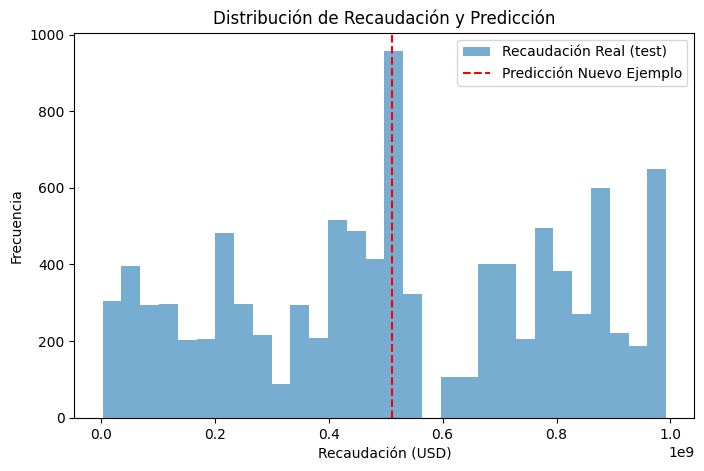

In [40]:
# 5. Predicción de nuevos ejemplos
#Creamos un nuevo registro con valores de las variables independientes
nuevo_ejemplo = pd.DataFrame({
    'Budget_USD': [100000000],   # Presupuesto
    'Duration': [120],           # Duración en minutos
    'Rating': [7.5],             # Puntuación promedio
    'Votes': [50000],            # Número de votos
    'Num_Awards': [3],           # Número de premios
    'Critic_Reviews': [150]      # Número de reseñas de críticos
})

# Predecir recaudación para el nuevo ejemplo
prediccion = model.predict(nuevo_ejemplo)[0]
print(f'Predicción de recaudación en taquilla: ${prediccion:,.2f}')

# Gráfico para mostrar dónde queda esta predicción dentro de la distribución real
plt.figure(figsize=(8,5))
plt.hist(y_test, bins=30, alpha=0.6, label='Recaudación Real (test)')
plt.axvline(prediccion, color='r', linestyle='--', label='Predicción Nuevo Ejemplo')
plt.title('Distribución de Recaudación y Predicción')
plt.xlabel('Recaudación (USD)')
plt.ylabel('Frecuencia')
plt.legend()
plt.show()